In [2]:
# ==========================================================
# ACC102 Track2 – US Automakers Financial Analysis
# Interactive Profit Query & Financial Comparison
# Data Source: WRDS Compustat 2020–2024
# For Car Buyers & Auto Enthusiasts
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wrds

# --------------------------
# 1. Load Data from WRDS
# --------------------------
db = wrds.Connection(wrds_username="your_wrds_username")

Enter your WRDS username [your_wrds_username]: jiamingwu
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\13951\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [3]:
# --------------------------
# 2. Write SQL
# --------------------------
sql = """
SELECT tic, conm, fyear, ni, sale, ebit
FROM comp.funda
WHERE tic IN ('F','GM','TSLA','RIVN','LCID')
AND fyear BETWEEN 2020 AND 2024
AND datafmt = 'STD' AND indfmt = 'INDL'
"""
df = db.raw_sql(sql)

# Calculate profit margin
df["profit_margin"] = df["ni"] / df["sale"]

# --------------------------
# RENAME METRICS FOR CLARITY|
# --------------------------
df = df.rename(columns={
    "tic": "Ticker",
    "fyear": "Year",
    "ni": "Net_Income",
    "sale": "Revenue",
    "ebit": "Operating_Profit",
    "profit_margin": "Net_Profit_Margin"
})

# Company name mapping
brands = {
    "F": "Ford",
    "GM": "General Motors",
    "TSLA": "Tesla",
    "RIVN": "Rivian",
    "LCID": "Lucid"
}
db.close()

In [4]:
# --------------------------
# 3. User Selection
# --------------------------
print("==== US Automakers Profit Analysis System ====")
print("Available companies:")
for tic, name in brands.items():
    print(f"- {tic}: {name}")

selected = input("\nEnter tickers to analyze (separate by comma): ").strip().upper()
selected_tics = [t.strip() for t in selected.split(",")]

# Filter data
filtered = df[df["Ticker"].isin(selected_tics)].copy()

==== US Automakers Profit Analysis System ====
Available companies:
- F: Ford
- GM: General Motors
- TSLA: Tesla
- RIVN: Rivian
- LCID: Lucid



Enter tickers to analyze (separate by comma):  F,TSLA


In [5]:
# --------------------------
# 4. Display 5-Year Profit Table
# --------------------------
print("\n===== 5-YEAR NET INCOME TABLE (in millions USD) =====")
pivot = filtered.pivot_table(index="Year", columns="Ticker", values="Net_Income")
print(pivot.round(2))


===== 5-YEAR NET INCOME TABLE (in millions USD) =====
Ticker        F     TSLA
Year                    
2020    -1279.0    721.0
2021    17937.0   5519.0
2022    -1981.0  12556.0
2023     4347.0  14997.0
2024     5879.0   7091.0


In [6]:
# --------------------------
# 5. Financial Performance Analysis
# --------------------------
print("\n===== FINANCIAL PERFORMANCE ANALYSIS =====")
analysis = pd.DataFrame({
    "Avg_Net_Income": pivot.mean(),
    "Highest_NI": pivot.max(),
    "Lowest_NI": pivot.min(),
    "CAGR_%": ((pivot.iloc[-1] / pivot.iloc[0]) ** (1/5) - 1) * 100
})
print(analysis.round(2))


===== FINANCIAL PERFORMANCE ANALYSIS =====
        Avg_Net_Income  Highest_NI  Lowest_NI  CAGR_%
Ticker                                               
F               4980.6     17937.0    -1981.0     NaN
TSLA            8176.8     14997.0      721.0   57.96


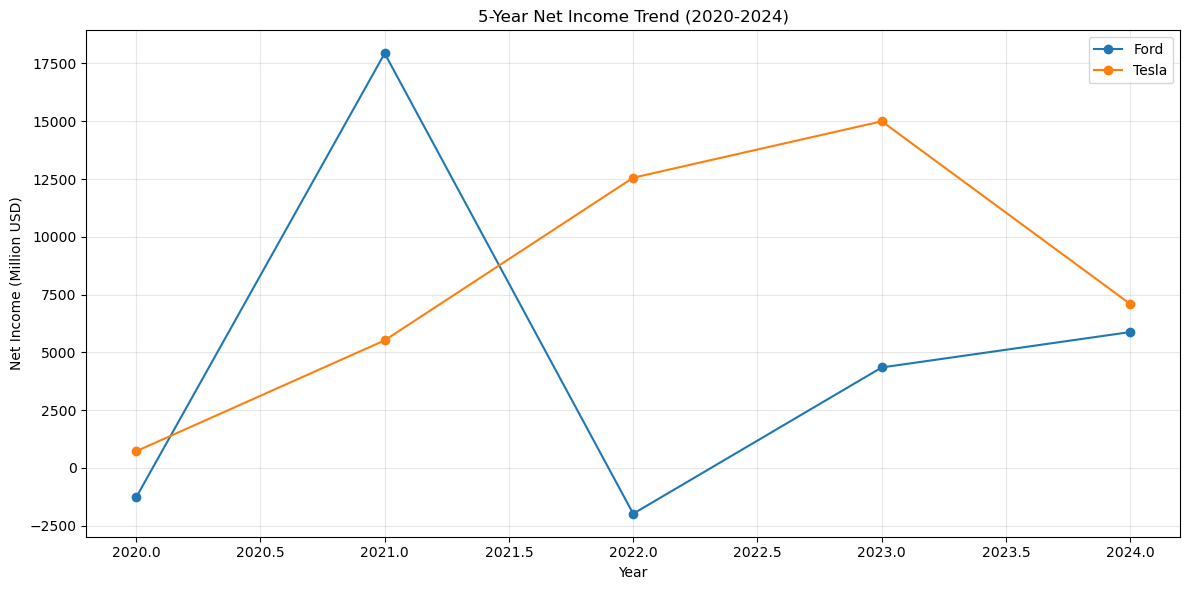


Chart saved as: figure_selected company_profit_trend.png


In [7]:
# --------------------------
# 6. Generate Profit Trend Chart
# --------------------------
plt.figure(figsize=(12, 6))
for tic in selected_tics:
    plt.plot(pivot.index, pivot[tic], marker="o", label=brands[tic])

plt.title("5-Year Net Income Trend (2020-2024)")
plt.xlabel("Year")
plt.ylabel("Net Income (Million USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("profit_trend.png", dpi=300)
plt.show()
print("\nChart saved as: figure_selected company_profit_trend.png")

In [8]:
# --------------------------
# 7. Export Files
# --------------------------
filtered.to_excel("data_selected company raw.xlsx", index=False)

analysis_reset = analysis.reset_index()
analysis_reset.to_excel("data_selected company analysis.xlsx", index=False)
